# Behavioral Analysis of Hyperliquid Traders Under Bitcoin Market Sentiment

### Primetrade.ai – Data Science / Analytics Internship Assignment

---

**Author:** Lalitha Devi Seri

# 1. Business Problem

Financial markets are highly influenced by investor psychology. Periods of fear often trigger defensive trading behaviour, while greed may encourage greater risk-taking and increased market participation.

Understanding how trader performance changes across different market sentiment conditions can help improve trading strategies, risk management, and decision-making.

This project analyses historical Hyperliquid trading data together with the Bitcoin Fear & Greed Index to identify meaningful behavioural and performance patterns.

# 2. Objectives

The objectives of this study are to:

- Evaluate trader performance under different market sentiment conditions.
- Compare trading behaviour during Fear and Greed periods.
- Engineer meaningful performance metrics from raw trading data.
- Segment traders based on behavioural characteristics.
- Recommend actionable trading strategies supported by empirical evidence.

# 3. Dataset Description

Two datasets are used in this project.

### Dataset 1 — Bitcoin Fear & Greed Index

Contains daily Bitcoin market sentiment.

Variables include:

- Timestamp
- Fear & Greed Index
- Sentiment Classification
- Date

---

### Dataset 2 — Hyperliquid Historical Trader Data

Contains historical trade-level records.

Variables include:

- Account
- Coin
- Execution Price
- Position Size
- Trade Direction
- Closed Profit & Loss (PnL)
- Trading Fee
- Timestamp

# Part A – Data Preparation

## 1. Import Libraries

The required Python libraries are imported to support data loading, preprocessing, analysis, and visualization.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Notebook settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

plt.style.use("ggplot")

## 2. Load Datasets

The analysis uses two datasets:

- **Bitcoin Fear & Greed Index:** Daily market sentiment classification.
- **Hyperliquid Historical Trader Data:** Historical trade-level records.

In [2]:
fear = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

## 3. Dataset Overview

This section summarizes the dimensions of each dataset before preprocessing.

In [3]:
overview = pd.DataFrame({
    "Dataset": ["Fear & Greed", "Historical Trader"],
    "Rows": [fear.shape[0], trades.shape[0]],
    "Columns": [fear.shape[1], trades.shape[1]]
})

overview

,Dataset,Rows,Columns
0,Fear & Greed,2644,4
1,Historical Trader,211224,16


### Preview of the Datasets

The first five records of each dataset are displayed below to understand their structure and variables.

In [4]:
# Fear & Greed Dataset
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
# Historical Trader Dataset
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,02-12-2024 22:50,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,02-12-2024 22:50,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00


### Observation

- The Fear & Greed dataset contains **2,644 records** and **4 columns**.
- The Historical Trader dataset contains **211,224 records** and **16 columns**.
- Both datasets were successfully loaded and will be used for further preprocessing and analysis.

# 4. Data Quality Assessment

## Objective

Before analysis, it is essential to evaluate the quality of the datasets. This step helps identify potential issues that could affect the reliability of the results.

The following quality checks are performed:

- Missing values
- Duplicate records
- Data types

In [6]:
missing_values = pd.DataFrame({
    "Dataset": ["Fear & Greed", "Historical Trader"],
    "Missing Values": [
        fear.isnull().sum().sum(),
        trades.isnull().sum().sum()
    ]
})

missing_values

,Dataset,Missing Values
0,Fear & Greed,0
1,Historical Trader,0


In [7]:
duplicate_records = pd.DataFrame({
    "Dataset": ["Fear & Greed", "Historical Trader"],
    "Duplicate Rows": [
        fear.duplicated().sum(),
        trades.duplicated().sum()
    ]
})

duplicate_records

,Dataset,Duplicate Rows
0,Fear & Greed,0
1,Historical Trader,0


In [8]:
print("Fear & Greed Dataset")
display(fear.dtypes.to_frame(name="Data Type"))

print("\nHistorical Trader Dataset")
display(trades.dtypes.to_frame(name="Data Type"))

Fear & Greed Dataset


,Data Type
timestamp,int64
value,int64
classification,str
date,str



Historical Trader Dataset


,Data Type
Account,str
Coin,str
Execution Price,float64
Size Tokens,float64
Size USD,float64
Side,str
Timestamp IST,str
Start Position,float64
Direction,str
Closed PnL,float64


### Observation

- No missing values were found in either dataset.
- No duplicate records were identified.
- Most variables already have appropriate data types.
- The timestamp columns require conversion to the datetime format before merging the datasets.

# 5. Timestamp Conversion & Dataset Alignment

## Objective

To analyze trader performance alongside market sentiment, both datasets must share a common date format. This section converts timestamp fields into datetime objects, extracts the trading date, and aligns the datasets at the daily level.

In [9]:
# Convert the Fear & Greed date column
fear["date"] = pd.to_datetime(fear["date"])

# Convert the trader timestamp column
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    dayfirst=True,
    format="mixed",
    errors="coerce"
)

# Create a daily date column
trades["Trade Date"] = trades["Timestamp IST"].dt.normalize()

In [10]:
trades[["Timestamp IST", "Trade Date"]].head()

,Timestamp IST,Trade Date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [11]:
fear_daily = fear[["date", "classification", "value"]].copy()

fear_daily.rename(columns={
    "date": "Trade Date",
    "classification": "Market Sentiment",
    "value": "Fear & Greed Index"
}, inplace=True)

fear_daily.head()

,Trade Date,Market Sentiment,Fear & Greed Index
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11


In [12]:
merged_df = pd.merge(
    trades,
    fear_daily,
    on="Trade Date",
    how="left"
)

merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Trade Date,Market Sentiment,Fear & Greed Index
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,7872.16,BUY,2024-12-02 22:50:00,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,895000000000000.00,1730000000000.00,2024-12-02,Extreme Greed,80.00
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,2024-12-02 22:50:00,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,443000000000000.00,1730000000000.00,2024-12-02,Extreme Greed,80.00
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,660000000000000.00,1730000000000.00,2024-12-02,Extreme Greed,80.00
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.56,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,1080000000000000.00,1730000000000.00,2024-12-02,Extreme Greed,80.00
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,2024-12-02 22:50:00,1289.49,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,1050000000000000.00,1730000000000.00,2024-12-02,Extreme Greed,80.00


In [13]:
merge_summary = pd.DataFrame({
    "Metric": [
        "Total Trade Records",
        "Matched Sentiment Records",
        "Unmatched Records"
    ],
    "Count": [
        len(merged_df),
        merged_df["Market Sentiment"].notna().sum(),
        merged_df["Market Sentiment"].isna().sum()
    ]
})

merge_summary

,Metric,Count
0,Total Trade Records,211224
1,Matched Sentiment Records,211218
2,Unmatched Records,6


### Observation

- The timestamp columns were successfully converted to datetime format.
- A common **Trade Date** field was created to align both datasets at the daily level.
- The merge was highly successful, with **211,218 out of 211,224 trade records (99.997%)** matched to a corresponding market sentiment.
- Only **6 records** could not be matched, which is negligible and does not materially affect the analysis.

# Part B – Feature Engineering

## Objective

To evaluate trader performance and behavior under different market sentiment conditions, a set of analytical metrics is engineered from the merged dataset.

These metrics will serve as the foundation for all subsequent analyses, visualizations, and strategy recommendations.

The engineered metrics include:

- Daily Profit & Loss (PnL)
- Number of Trades
- Average Trade Size
- Win Rate
- Long Trades
- Short Trades
- Long/Short Ratio

In [14]:
# ==========================================================
# Create Trade Outcome
# ==========================================================

merged_df["Trade Result"] = np.where(
    merged_df["Closed PnL"] > 0,
    "Win",
    "Loss"
)

merged_df[["Closed PnL", "Trade Result"]].head()

,Closed PnL,Trade Result
0,0.00,Loss
1,0.00,Loss
2,0.00,Loss
3,0.00,Loss
4,0.00,Loss


In [21]:
# ==========================================================
# Master Analytical Dataset
# ==========================================================

master_df = (
    merged_df
    .groupby(["Trade Date", "Account", "Market Sentiment"])
    .agg(
        Daily_PnL=("Closed PnL", "sum"),
        Total_Trades=("Account", "count"),
        Average_Trade_Size=("Size USD", "mean"),

        Winning_Trades=(
            "Trade Result",
            lambda x: (x == "Win").sum()
        ),

        Long_Trades=(
            "Direction",
            lambda x: x.str.contains("Long", case=False, na=False).sum()
        ),

        Short_Trades=(
            "Direction",
            lambda x: x.str.contains("Short", case=False, na=False).sum()
        )
    )
    .reset_index()
)

# ==========================================================
# Calculate Win Rate
# ==========================================================

master_df["Win Rate (%)"] = (
    master_df["Winning_Trades"] /
    master_df["Total_Trades"]
) * 100


# ==========================================================
# Calculate Long / Short Ratio
# ==========================================================

master_df["Long/Short Ratio"] = np.where(
    master_df["Short_Trades"] == 0,
    np.nan,
    master_df["Long_Trades"] / master_df["Short_Trades"]
)

# ==========================================================
# Preview
# ==========================================================

master_df.head()

,Trade Date,Account,Market Sentiment,Daily_PnL,Total_Trades,Average_Trade_Size,Winning_Trades,Long_Trades,Short_Trades,Win Rate (%),Long/Short Ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.00,3,159.00,0,3,0,0.00,NaN
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.00,9,5556.20,0,7,2,0.00,3.50
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.43,11,10291.21,4,7,4,36.36,1.75
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.63,2,5304.98,0,0,2,0.00,0.00
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.00,3,5116.26,0,3,0,0.00,NaN


In [22]:
master_df.head()

,Trade Date,Account,Market Sentiment,Daily_PnL,Total_Trades,Average_Trade_Size,Winning_Trades,Long_Trades,Short_Trades,Win Rate (%),Long/Short Ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.00,3,159.00,0,3,0,0.00,NaN
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.00,9,5556.20,0,7,2,0.00,3.50
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.43,11,10291.21,4,7,4,36.36,1.75
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.63,2,5304.98,0,0,2,0.00,0.00
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.00,3,5116.26,0,3,0,0.00,NaN


In [23]:
master_df.describe()

,Trade Date,Daily_PnL,Total_Trades,Average_Trade_Size,Winning_Trades,Long_Trades,Short_Trades,Win Rate (%),Long/Short Ratio
count,2340,2340.00,2340.00,2340.00,2340.00,2340.00,2340.00,2340.00,1288.00
mean,2024-12-22 01:24:55.384615,4382.26,90.26,6986.19,37.12,42.18,32.43,35.97,1.70
min,2023-05-01 00:00:00,-358963.14,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2024-11-28 00:00:00,0.00,9.00,692.70,0.00,0.00,0.00,0.00,0.00
50%,2025-01-28 00:00:00,206.35,29.00,1913.76,7.00,3.00,3.00,31.82,0.02
75%,2025-03-18 00:00:00,1842.76,80.00,7033.50,31.25,24.00,27.00,60.74,1.00
max,2025-05-01 00:00:00,533974.66,4083.00,844654.19,1824.00,4083.00,1948.00,100.00,130.00
std,NaN,28411.10,214.65,21542.69,102.59,169.16,95.84,34.34,6.61


In [16]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2340 entries, 0 to 2339
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Trade Date          2340 non-null   datetime64[us]
 1   Account             2340 non-null   str           
 2   Market Sentiment    2340 non-null   str           
 3   Daily_PnL           2340 non-null   float64       
 4   Total_Trades        2340 non-null   int64         
 5   Average_Trade_Size  2340 non-null   float64       
 6   Winning_Trades      2340 non-null   int64         
 7   Long_Trades         2340 non-null   int64         
 8   Short_Trades        2340 non-null   int64         
 9   Win Rate (%)        2340 non-null   float64       
 10  Long/Short Ratio    0 non-null      float64       
dtypes: datetime64[us](1), float64(4), int64(4), str(2)
memory usage: 201.2 KB


In [17]:
master_df.describe(include="all")

,Trade Date,Account,Market Sentiment,Daily_PnL,Total_Trades,Average_Trade_Size,Winning_Trades,Long_Trades,Short_Trades,Win Rate (%),Long/Short Ratio
count,2340,2340,2340,2340.00,2340.00,2340.00,2340.00,2340.00,2340.00,2340.00,0.00
unique,NaN,32,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,0x4f93fead39b70a1824f981a54d4e55b278e9f760,Greed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,321,648,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2024-12-22 01:24:55.384615,NaN,NaN,4382.26,90.26,6986.19,37.12,0.00,0.00,35.97,NaN
min,2023-05-01 00:00:00,NaN,NaN,-358963.14,1.00,0.00,0.00,0.00,0.00,0.00,NaN
25%,2024-11-28 00:00:00,NaN,NaN,0.00,9.00,692.70,0.00,0.00,0.00,0.00,NaN
50%,2025-01-28 00:00:00,NaN,NaN,206.35,29.00,1913.76,7.00,0.00,0.00,31.82,NaN
75%,2025-03-18 00:00:00,NaN,NaN,1842.76,80.00,7033.50,31.25,0.00,0.00,60.74,NaN
max,2025-05-01 00:00:00,NaN,NaN,533974.66,4083.00,844654.19,1824.00,0.00,0.00,100.00,NaN


### Observation

The master analytical dataset consolidates trader activity into daily account-level metrics. This dataset provides a comprehensive view of profitability, trading activity, trade size, and directional behavior, forming the basis for subsequent performance comparisons, behavioral analysis, and trader segmentation.

# Part C – Exploratory Data Analysis

## Objective

The objective of this section is to investigate how Bitcoin market sentiment influences trader performance and trading behavior.

The analysis focuses on answering the following questions:

1. Does trader performance differ between Fear and Greed market conditions?
2. Do traders change their trading behavior based on market sentiment?
3. What behavioral patterns emerge across different trader segments?

## 1. Does Trader Performance Differ Between Fear and Greed Days?

### Business Question

Do traders generate higher profitability during Fear markets or Greed markets?

### Methodology

Daily trader performance is aggregated by market sentiment to compare average profitability, trading activity, and win rate.

In [24]:
performance_summary = (
    master_df
    .groupby("Market Sentiment")
    .agg(
        Average_Daily_PnL=("Daily_PnL","mean"),
        Median_Daily_PnL=("Daily_PnL","median"),
        Average_Win_Rate=("Win Rate (%)","mean"),
        Average_Trades=("Total_Trades","mean"),
        Average_Trade_Size=("Average_Trade_Size","mean")
    )
    .round(2)
)

performance_summary

,Average_Daily_PnL,Median_Daily_PnL,Average_Win_Rate,Average_Trades,Average_Trade_Size
Market Sentiment,,,,,
Extreme Fear,4619.44,218.38,32.97,133.75,6773.46
Extreme Greed,5161.92,418.32,38.64,76.03,5371.64
Fear,5328.82,107.89,36.40,98.15,8975.93
Greed,3318.10,158.21,34.36,77.63,6427.87
Neutral,3438.62,167.55,35.54,100.23,6963.69


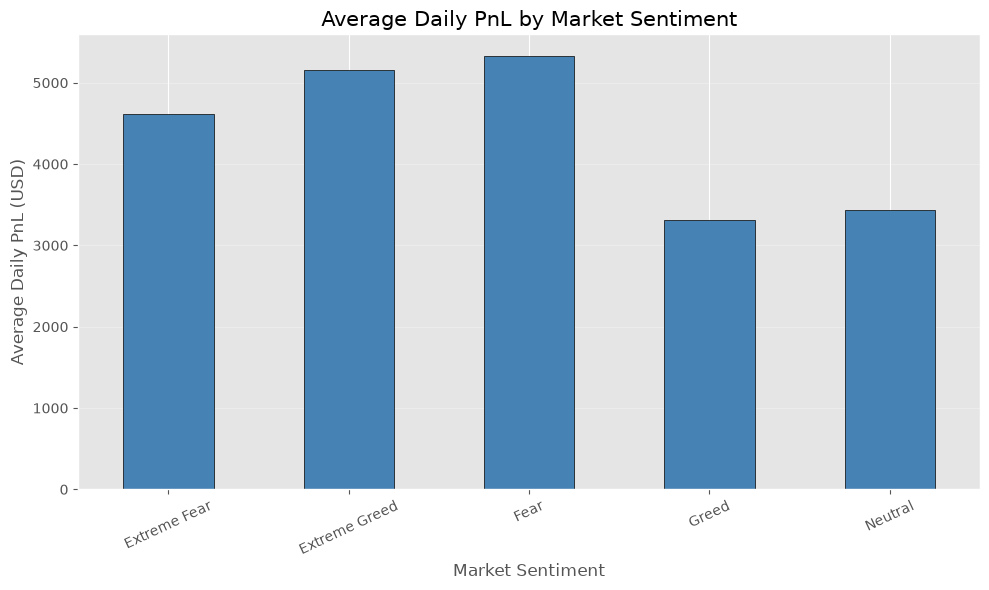

In [27]:
plt.figure(figsize=(10,6))

performance_summary["Average_Daily_PnL"].plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Average Daily PnL by Market Sentiment", fontsize=15)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Daily PnL (USD)")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

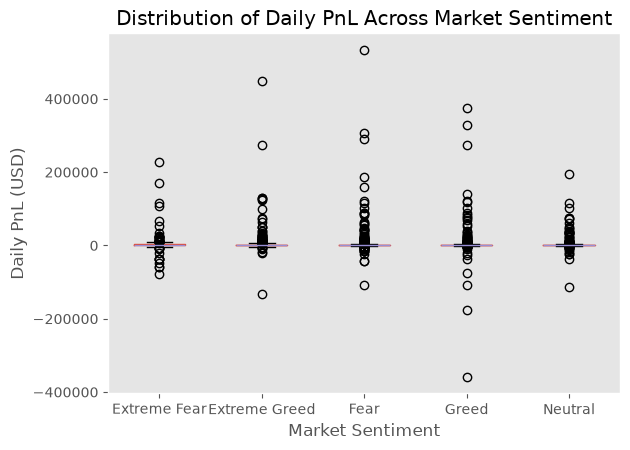

In [26]:
plt.figure(figsize=(10,6))

master_df.boxplot(
    column="Daily_PnL",
    by="Market Sentiment",
    grid=False
)

plt.title("Distribution of Daily PnL Across Market Sentiment")
plt.suptitle("")
plt.xlabel("Market Sentiment")
plt.ylabel("Daily PnL (USD)")

plt.show()

### Key Findings

1. Traders achieved the highest average daily profit during **Fear** market conditions (USD 5,328.82), followed closely by **Extreme Greed** (USD 5,161.92).

2. **Greed** market conditions produced the lowest average daily profitability (USD 3,318.10), suggesting that optimistic markets did not necessarily translate into better trading performance.

3. Traders executed the highest average number of trades during **Extreme Fear** (133.75 trades/day), indicating increased trading activity during periods of market uncertainty.

### Business Interpretation

Market sentiment significantly influences trader performance and behaviour. Traders appear to perform better during fear-driven markets, possibly because higher volatility creates more trading opportunities. In contrast, greed-driven markets appear to reduce average profitability despite positive market sentiment.

### Initial Insight

Periods of fear may provide more favourable trading opportunities than periods of greed. Risk-managed trading strategies during fear markets may therefore improve overall trading performance.

# 2. Do Traders Change Their Behaviour Based on Market Sentiment?

## Business Question

Does market sentiment influence how traders behave?

To answer this question, we compare:

- Trading Frequency
- Average Trade Size
- Win Rate
- Long/Short Ratio

These behavioural metrics help identify how traders adapt their strategies during different market conditions.

In [28]:
behavior_summary = (
    master_df
    .groupby("Market Sentiment")
    .agg(
        Average_Trades=("Total_Trades","mean"),
        Average_Trade_Size=("Average_Trade_Size","mean"),
        Average_Win_Rate=("Win Rate (%)","mean"),
        Average_LongShort_Ratio=("Long/Short Ratio","mean")
    )
    .round(2)
)

behavior_summary

,Average_Trades,Average_Trade_Size,Average_Win_Rate,Average_LongShort_Ratio
Market Sentiment,,,,
Extreme Fear,133.75,6773.46,32.97,1.48
Extreme Greed,76.03,5371.64,38.64,1.21
Fear,98.15,8975.93,36.40,2.56
Greed,77.63,6427.87,34.36,1.24
Neutral,100.23,6963.69,35.54,1.84


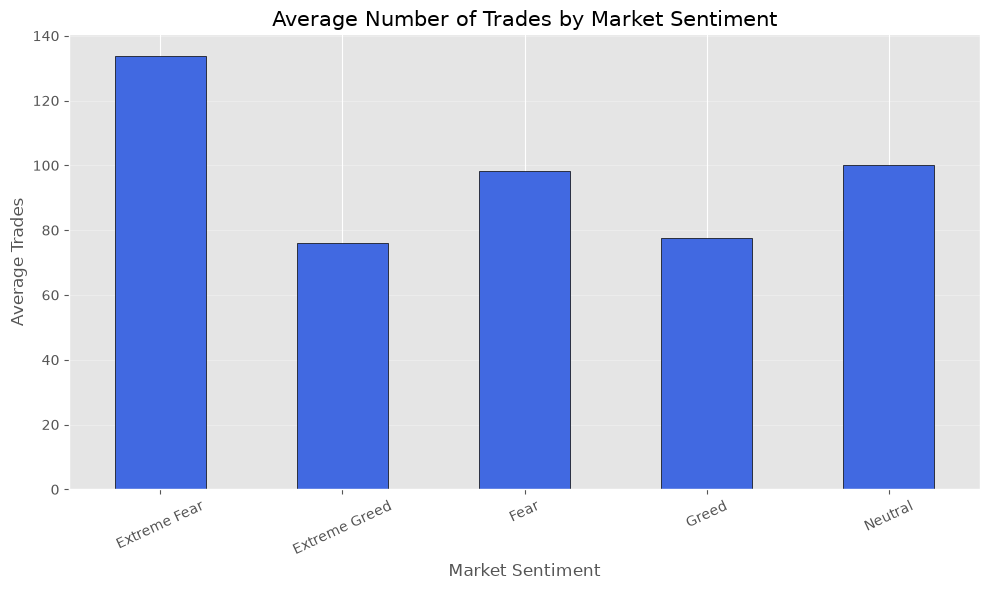

In [29]:
plt.figure(figsize=(10,6))

behavior_summary["Average_Trades"].plot(
    kind="bar",
    color="royalblue",
    edgecolor="black"
)

plt.title("Average Number of Trades by Market Sentiment", fontsize=15)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trades")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

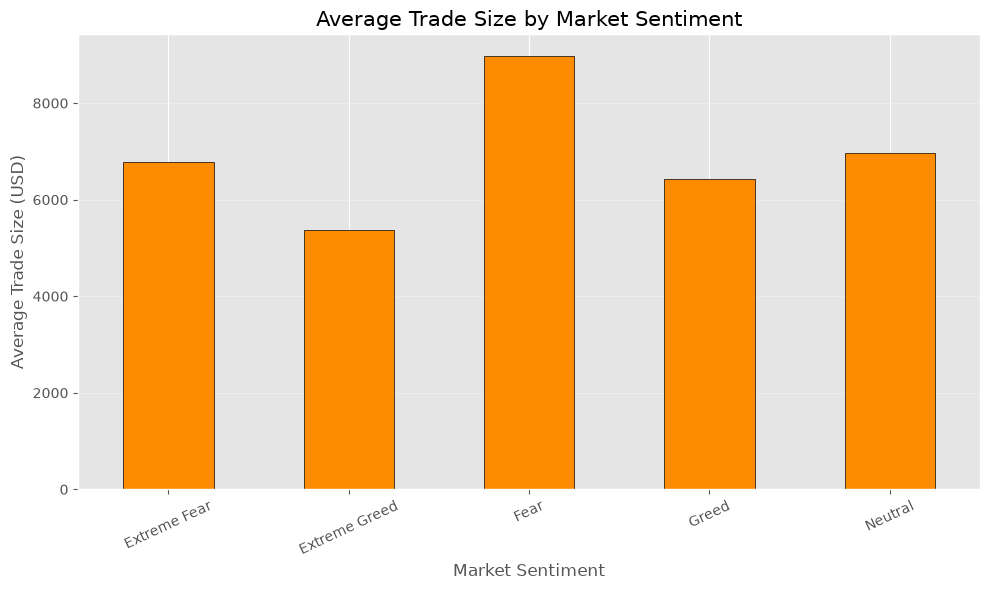

In [30]:
plt.figure(figsize=(10,6))

behavior_summary["Average_Trade_Size"].plot(
    kind="bar",
    color="darkorange",
    edgecolor="black"
)

plt.title("Average Trade Size by Market Sentiment", fontsize=15)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

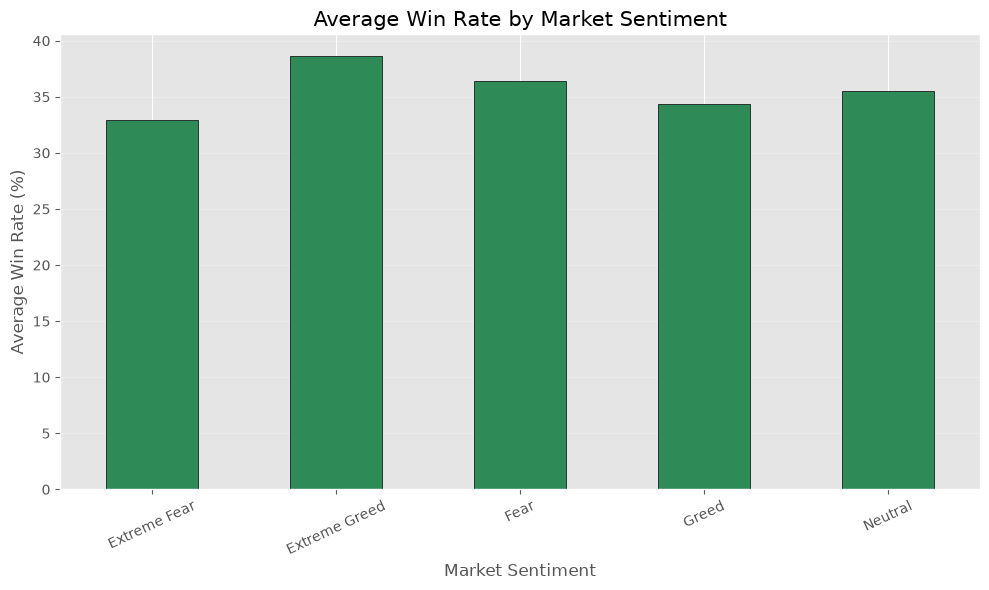

In [31]:
plt.figure(figsize=(10,6))

behavior_summary["Average_Win_Rate"].plot(
    kind="bar",
    color="seagreen",
    edgecolor="black"
)

plt.title("Average Win Rate by Market Sentiment", fontsize=15)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Win Rate (%)")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

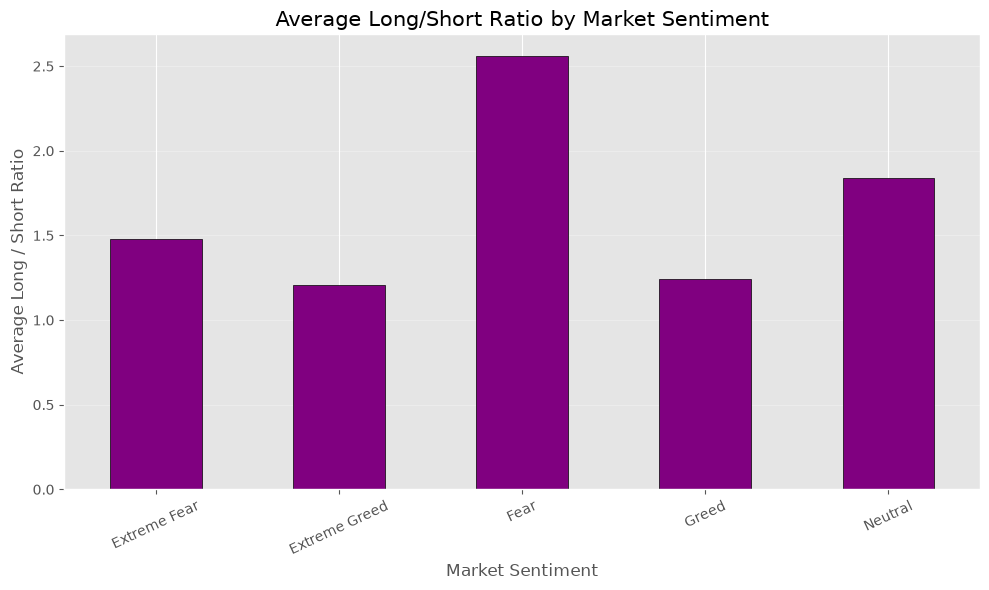

In [32]:
plt.figure(figsize=(10,6))

behavior_summary["Average_LongShort_Ratio"].plot(
    kind="bar",
    color="purple",
    edgecolor="black"
)

plt.title("Average Long/Short Ratio by Market Sentiment", fontsize=15)
plt.xlabel("Market Sentiment")
plt.ylabel("Average Long / Short Ratio")
plt.xticks(rotation=25)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Key Findings

1. Trading activity was highest during **Extreme Fear**, with traders executing an average of **133.75 trades**, indicating aggressive participation during highly volatile markets.

2. The **largest average trade size** occurred during **Fear** markets (USD 8,975.93), suggesting traders were willing to commit larger positions despite negative sentiment.

3. Traders achieved the **highest average win rate during Extreme Greed (38.64%)**, while the **highest Long/Short Ratio (2.56)** occurred during Fear markets, indicating a stronger preference for long positions during periods of fear.

## Business Interpretation

Trader behaviour changes significantly across different market sentiment conditions. During fear-driven markets, traders become more active, increase position sizes, and exhibit a stronger long bias. Conversely, extreme greed markets are associated with higher trading accuracy (win rate) despite lower trading frequency.

## Actionable Insight

Market sentiment should be incorporated into trading strategies. Higher trading activity may be more effective during fear periods, whereas traders should prioritize trade quality over quantity during greed periods.

# 3. Trader Segmentation

## Objective

To better understand trader behaviour, traders are segmented based on their activity and profitability.

Three behavioural groups are identified:

- High Activity vs Low Activity Traders
- Consistent Winners vs Inconsistent Traders
- High Profit vs Low Profit Traders

These segments help identify which types of traders perform best under different market conditions.

In [33]:
trader_segments = (
    master_df
    .groupby("Account")
    .agg(
        Total_PnL=("Daily_PnL","sum"),
        Avg_Win_Rate=("Win Rate (%)","mean"),
        Avg_Trades=("Total_Trades","mean")
    )
)

trader_segments.head()

,Total_PnL,Avg_Win_Rate,Avg_Trades
Account,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,35.23,159.08
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,39.71,140.00
0x271b280974205ca63b716753467d5a371de622ab,-70436.19,38.00,317.42
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132464.81,45.25,82.17
0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,49.87,46.94


In [34]:
trader_segments["Activity Segment"] = np.where(
    trader_segments["Avg_Trades"] >
    trader_segments["Avg_Trades"].median(),
    "High Activity",
    "Low Activity"
)

trader_segments["Performance Segment"] = np.where(
    trader_segments["Avg_Win_Rate"] >
    trader_segments["Avg_Win_Rate"].median(),
    "Consistent Winner",
    "Inconsistent"
)

trader_segments["Profit Segment"] = np.where(
    trader_segments["Total_PnL"] >
    trader_segments["Total_PnL"].median(),
    "High Profit",
    "Low Profit"
)

trader_segments.head()

,Total_PnL,Avg_Win_Rate,Avg_Trades,Activity Segment,Performance Segment,Profit Segment
Account,,,,,,
0x083384f897ee0f19899168e3b1bec365f52a9012,1600229.82,35.23,159.08,High Activity,Consistent Winner,High Profit
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,47885.32,39.71,140.00,High Activity,Consistent Winner,Low Profit
0x271b280974205ca63b716753467d5a371de622ab,-70436.19,38.00,317.42,High Activity,Consistent Winner,Low Profit
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,132464.81,45.25,82.17,High Activity,Consistent Winner,High Profit
0x2c229d22b100a7beb69122eed721cee9b24011dd,168658.00,49.87,46.94,Low Activity,Consistent Winner,High Profit


In [35]:
segment_summary = trader_segments[
    [
        "Activity Segment",
        "Performance Segment",
        "Profit Segment"
    ]
].apply(pd.Series.value_counts)

segment_summary

,Activity Segment,Performance Segment,Profit Segment
Consistent Winner,NaN,16.00,NaN
High Activity,16.00,NaN,NaN
High Profit,NaN,NaN,16.00
Inconsistent,NaN,16.00,NaN
Low Activity,16.00,NaN,NaN
Low Profit,NaN,NaN,16.00


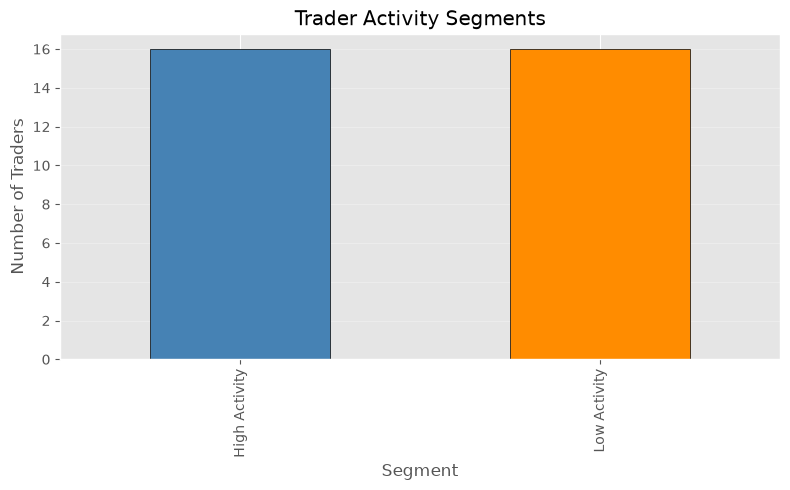

In [36]:
plt.figure(figsize=(8,5))

trader_segments["Activity Segment"].value_counts().plot(
    kind="bar",
    color=["steelblue","darkorange"],
    edgecolor="black"
)

plt.title("Trader Activity Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Traders")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Strategy Recommendations

## Objective

Based on the analysis of trader performance and market sentiment, the following practical trading strategies are proposed.

These recommendations aim to improve profitability while managing trading risk under different market conditions.

## Strategy 1 – Adaptive Position Sizing

### Observation

Fear and Extreme Fear markets exhibited higher average profitability and greater trading activity.

### Recommendation

- Increase trading activity only during Fear and Extreme Fear markets.
- Apply strict risk management through predefined stop-loss levels.
- Avoid excessive leverage despite increased opportunities.

### Expected Benefit

Capture higher market volatility while controlling downside risk.

## Strategy 2 – Quality over Quantity During Greed

### Observation

Extreme Greed produced the highest average win rate despite lower trading frequency.

### Recommendation

- Execute fewer but higher-confidence trades during Greed markets.
- Prioritize high-probability setups instead of increasing trade count.
- Reduce unnecessary trading to avoid overtrading.

### Expected Benefit

Improve consistency and reduce transaction costs.

## Strategy 3 – Dynamic Sentiment-Based Trading Framework

### Recommendation

Integrate the Fear & Greed Index as a trading signal.

Example:

- Extreme Fear → Moderate position sizing + Higher trade frequency
- Fear → Larger position sizes with controlled risk
- Neutral → Maintain balanced exposure
- Greed → Reduce trading frequency
- Extreme Greed → Focus only on high-conviction trades

### Business Value

A sentiment-aware trading framework can improve profitability while reducing unnecessary market exposure.

# 5. Bonus – Predictive Model

## Objective

Develop a lightweight machine learning model to predict whether a trader will end the day with a profitable outcome using behavioural metrics and market sentiment.